In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [36]:
# -------------------------------------------------
# 1. Load the data
# -------------------------------------------------
data = pd.read_csv('Telco_Customer_Churn_Dataset  (3).csv')
print("Data loaded. Shape:", data.shape)
print("\nFirst few rows:\n", data.head(10))


Data loaded. Shape: (7043, 21)

First few rows:
    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
6  1452-KIOVK    Male              0      No        Yes      22          Yes   
7  6713-OKOMC  Female              0      No         No      10           No   
8  7892-POOKP  Female              0     Yes         No      28          Yes   
9  6388-TABGU    Male              0      No        Yes      62          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtecti

In [37]:
# -------------------------------------------------
# 2. Quick look at what we have
# -------------------------------------------------
print("\n--- Dataset info ---")
print(data.info())

print("\n--- Numeric stats ---")
print(data.describe())

# Check missing values – TotalCharges looks suspicious
print("\n--- Missing values before fix ---")
print(data.isnull().sum())



--- Dataset info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  70

In [38]:
# -------------------------------------------------
# 3. Fix TotalCharges – it's stored as string with some blanks
# -------------------------------------------------
# Convert to number, invalid entries become NaN

data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

# Drop the few rows where TotalCharges is NaN (only a couple)
data = data.dropna(subset=['TotalCharges'])

print("\nMissing after fix:\n", data.isnull().sum())
print("New shape after dropping NaNs:", data.shape)


Missing after fix:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
New shape after dropping NaNs: (7032, 21)


In [39]:
# -------------------------------------------------
# 4. Convert categorical columns to numbers
# -------------------------------------------------
# First, target variable Churn -> 1 for Yes, 0 for No
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})

# For other categorical columns, we'll use one-hot encoding
# But we skip customerID because it's just an ID
cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
            'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
            'PaperlessBilling', 'PaymentMethod']

# Use pandas get_dummies – simple and works
data_encoded = pd.get_dummies(data, columns=cat_cols, drop_first=True)

print("\nShape after encoding:", data_encoded.shape)
print("\nColumns now:\n", data_encoded.columns.tolist())



Shape after encoding: (7032, 32)

Columns now:
 ['customerID', 'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [40]:
# -------------------------------------------------
# 5. Split into train and test (80/20)
# -------------------------------------------------

# Separate features and target
X = data_encoded.drop(['customerID', 'Churn'], axis=1)
y = data_encoded['Churn']

# Splitt with stratification to keep churn ratio similar
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTraining set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("Churn % in training:", round(y_train.mean()*100,2))
print("Churn % in test:", round(y_test.mean()*100,2))


Training set size: (5625, 30)
Test set size: (1407, 30)
Churn % in training: 26.58
Churn % in test: 26.58


In [41]:
print("\nTask 1 completed successfully!")


Task 1 completed successfully!


In [59]:
# ============================================
# Task 2 – Exploratory Data Analysis (EDA)
# Using only matplotlib (no seaborn needed)
# ============================================

import matplotlib.pyplot as plt
import pandas as pd

In [47]:
# -------------------------------------------------
# 1. Overall churn rate
# -------------------------------------------------
churn_rate = data['Churn'].mean() * 100
print(f"Overall churn rate: {churn_rate:.2f}%")


Overall churn rate: 26.58%


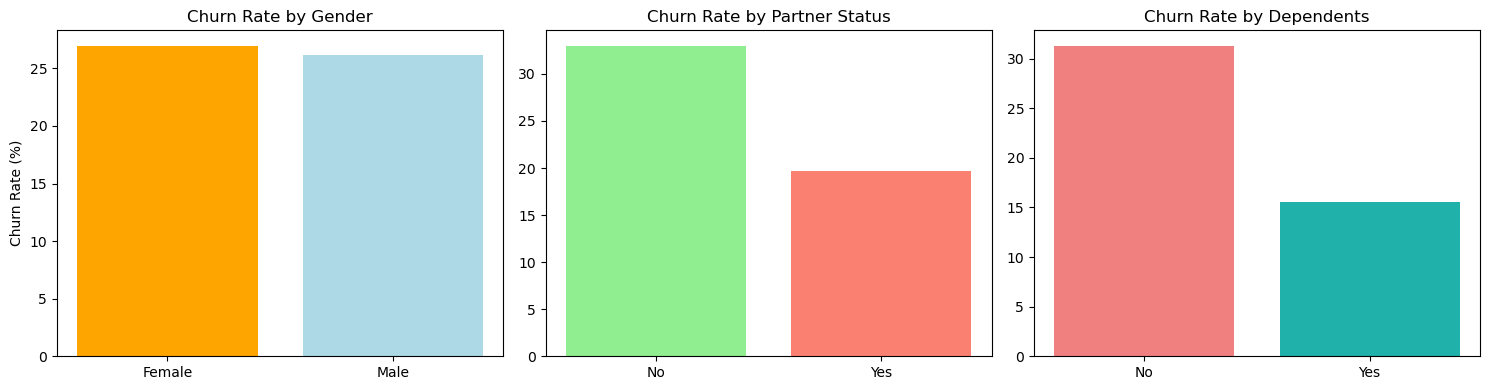

In [49]:
# -------------------------------------------------
# 2. Churn by gender, partner, dependents
# -------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gender
gender_churn = data.groupby('gender')['Churn'].mean() * 100
axes[0].bar(gender_churn.index, gender_churn.values, color=['orange', 'lightblue'])
axes[0].set_title('Churn Rate by Gender')
axes[0].set_ylabel('Churn Rate (%)')

# Partner
partner_churn = data.groupby('Partner')['Churn'].mean() * 100
axes[1].bar(partner_churn.index, partner_churn.values, color=['lightgreen', 'salmon'])
axes[1].set_title('Churn Rate by Partner Status')

# Dependents
dep_churn = data.groupby('Dependents')['Churn'].mean() * 100
axes[2].bar(dep_churn.index, dep_churn.values, color=['lightcoral', 'lightseagreen'])
axes[2].set_title('Churn Rate by Dependents')

plt.tight_layout()
plt.show()


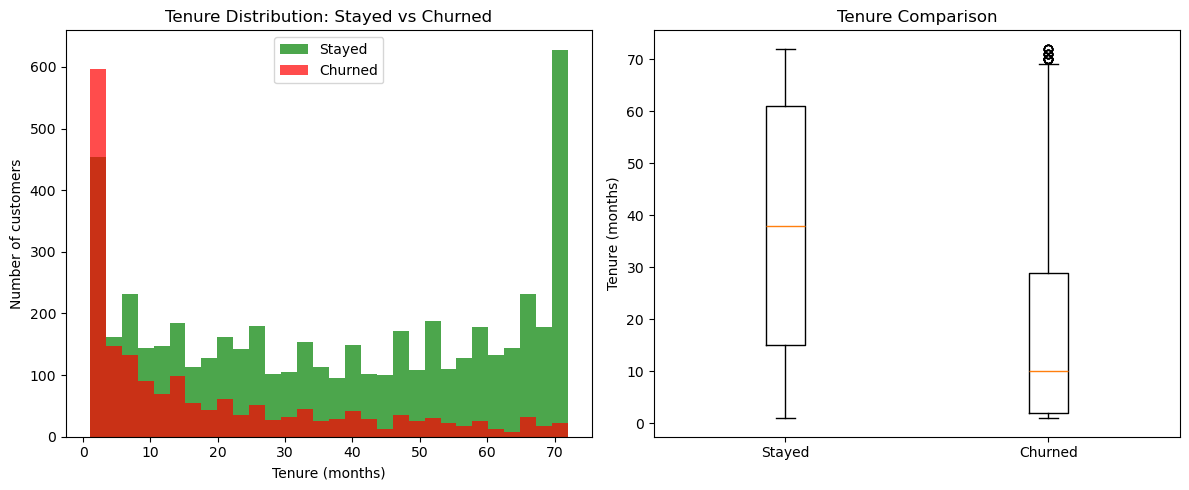

In [51]:
# -------------------------------------------------
# 3. Tenure distribution and relation with churn
# -------------------------------------------------
plt.figure(figsize=(12, 5))

# Histogram (using matplotlib directly)
plt.subplot(1, 2, 1)
plt.hist(data[data['Churn']==0]['tenure'], bins=30, alpha=0.7, label='Stayed', color='green')
plt.hist(data[data['Churn']==1]['tenure'], bins=30, alpha=0.7, label='Churned', color='red')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of customers')
plt.legend()
plt.title('Tenure Distribution: Stayed vs Churned')

# Boxplot using matplotlib (requires separate calculation)
plt.subplot(1, 2, 2)
stayed_tenure = data[data['Churn']==0]['tenure']
churned_tenure = data[data['Churn']==1]['tenure']
box_data = [stayed_tenure, churned_tenure]
plt.boxplot(box_data, labels=['Stayed', 'Churned'])
plt.title('Tenure Comparison')
plt.ylabel('Tenure (months)')

plt.tight_layout()
plt.show()

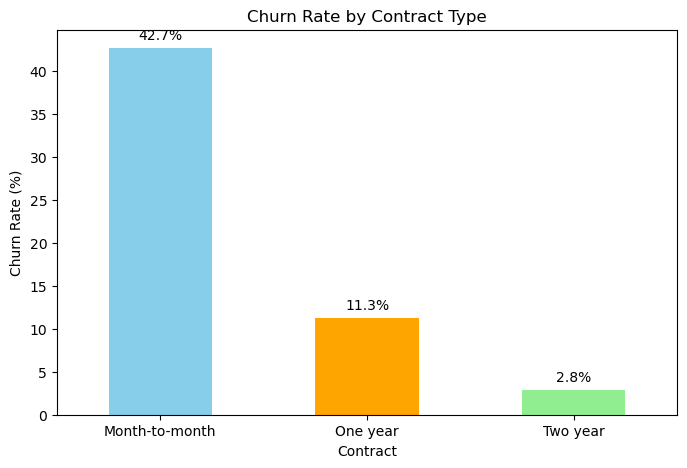

In [52]:
# -------------------------------------------------
# 4. Churn by contract type
# -------------------------------------------------
plt.figure(figsize=(8,5))
contract_churn = data.groupby('Contract')['Churn'].mean() * 100
contract_churn.plot(kind='bar', color=['skyblue', 'orange', 'lightgreen'])
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
for i, v in enumerate(contract_churn):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')
plt.show()

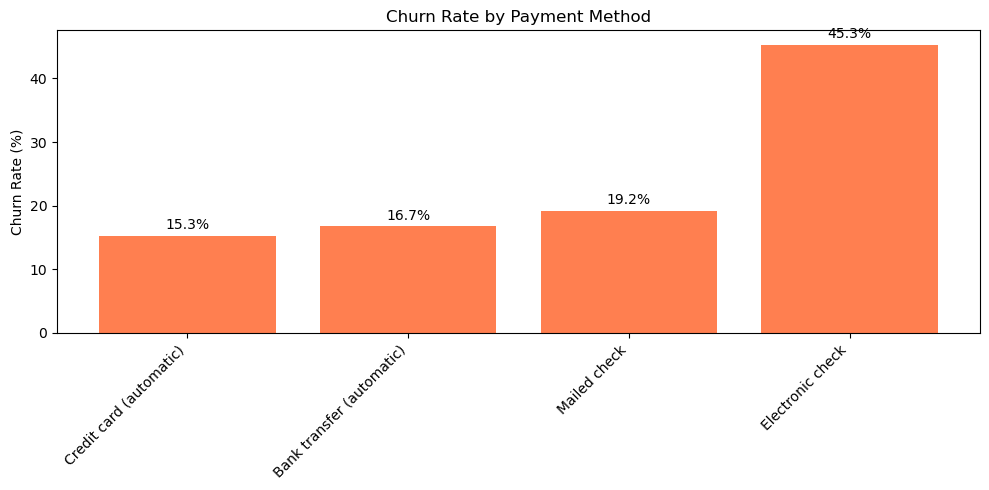

In [55]:
# -------------------------------------------------
# 5. Churn by payment method
# -------------------------------------------------
plt.figure(figsize=(10,5))
payment_churn = data.groupby('PaymentMethod')['Churn'].mean() * 100
payment_churn_sorted = payment_churn.sort_values()
plt.bar(payment_churn_sorted.index, payment_churn_sorted.values, color='coral')
plt.title('Churn Rate by Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(payment_churn_sorted):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')
plt.tight_layout()
plt.show()

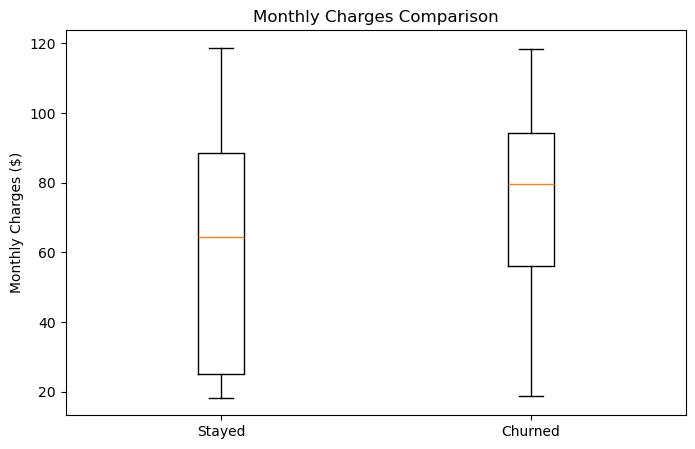

In [56]:
# -------------------------------------------------
# 6. Monthly charges vs churn (boxplot)
# -------------------------------------------------
plt.figure(figsize=(8,5))
stayed_charges = data[data['Churn']==0]['MonthlyCharges']
churned_charges = data[data['Churn']==1]['MonthlyCharges']
plt.boxplot([stayed_charges, churned_charges], labels=['Stayed', 'Churned'])
plt.title('Monthly Charges Comparison')
plt.ylabel('Monthly Charges ($)')
plt.show()


In [61]:
# ============================================
# Task 3 – Customer Segmentation
# Finding groups with high churn and risky high-value customers
# ============================================



In [63]:
# Defining bins for tenure (months)
tenure_bins = [0, 12, 24, 48, 72, 100]  # groups: <1yr, 1-2yr, 2-4yr, 4-6yr, 6yr+
tenure_labels = ['<12 months', '12-24 months', '24-48 months', '48-72 months', '>72 months']
data['tenure_group'] = pd.cut(data['tenure'], bins=tenure_bins, labels=tenure_labels, right=False)

# Calculatimg churn rate by tenure group
tenure_churn = data.groupby('tenure_group', observed=False)['Churn'].mean() * 100
print("=== Churn Rate by Tenure Group ===")
print(tenure_churn.round(2))
print()


=== Churn Rate by Tenure Group ===
tenure_group
<12 months      48.54
12-24 months    29.51
24-48 months    20.87
48-72 months    11.13
>72 months       1.66
Name: Churn, dtype: float64



In [64]:
# -------------------------------------------------
# 2. Create monthly charges segments (low, medium, high)
# -------------------------------------------------
# Using quantiles (33rd and 66th percentiles)
low_q = data['MonthlyCharges'].quantile(0.33)
high_q = data['MonthlyCharges'].quantile(0.66)

def charge_group(charge):
    if charge <= low_q:
        return 'Low (<=33rd)'
    elif charge <= high_q:
        return 'Medium (33rd-66th)'
    else:
        return 'High (>66th)'

data['charge_group'] = data['MonthlyCharges'].apply(charge_group)

charge_churn = data.groupby('charge_group')['Churn'].mean() * 100
print("=== Churn Rate by Monthly Charges Group ===")
print(charge_churn.round(2))
print()

=== Churn Rate by Monthly Charges Group ===
charge_group
High (>66th)          34.25
Low (<=33rd)          15.81
Medium (33rd-66th)    29.44
Name: Churn, dtype: float64



In [66]:
# -------------------------------------------------
# 3. Contract type (already categorical)
# -------------------------------------------------
contract_churn = data.groupby('Contract')['Churn'].mean() * 100
print("=== Churn Rate by Contract Type ===")
print(contract_churn.round(2))
print()


=== Churn Rate by Contract Type ===
Contract
Month-to-month    42.71
One year          11.28
Two year           2.85
Name: Churn, dtype: float64



In [67]:
# -------------------------------------------------
# 4. Combined segmentation: Contract + Tenure
# -------------------------------------------------
combined_churn = data.groupby(['Contract', 'tenure_group'], observed=False)['Churn'].mean() * 100
print("=== Churn Rate by Contract & Tenure Group ===")
print(combined_churn.round(2))
print()

=== Churn Rate by Contract & Tenure Group ===
Contract        tenure_group
Month-to-month  <12 months      51.94
                12-24 months    37.65
                24-48 months    33.61
                48-72 months    25.92
                >72 months       0.00
One year        <12 months       7.92
                12-24 months    10.55
                24-48 months     9.80
                48-72 months    13.18
                >72 months      11.76
Two year        <12 months       0.00
                12-24 months     0.00
                24-48 months     1.86
                48-72 months     4.14
                >72 months       1.17
Name: Churn, dtype: float64



In [71]:
# -------------------------------------------------
# 5. Identify high-value customers at risk
# -------------------------------------------------
# Defining high-value: MonthlyCharges > 80th percentile AND tenure > 24 months
high_value_threshold = data['MonthlyCharges'].quantile(0.8)
high_value_customers = data[(data['MonthlyCharges'] > high_value_threshold) & (data['tenure'] > 24)]

# Among these, which are at risk (churned or likely to churn)
at_risk_high_value = high_value_customers[high_value_customers['Churn'] == 1]

print(f"=== High-Value Customer Analysis ===")
print(f"Total high-value customers (high charges + >24 months tenure): {len(high_value_customers)}")
print(f"Of these, churned: {len(at_risk_high_value)} ({len(at_risk_high_value)/len(high_value_customers)*100:.2f}%)")
print()

# Show first few at-risk high-value customers
if len(at_risk_high_value) > 0:
    print("Sample of at-risk high-value customers:")
    print(at_risk_high_value[['customerID', 'tenure', 'MonthlyCharges', 'Contract', 'Churn']].head())
else:
    print("No high-value customers churned in this dataset.")

=== High-Value Customer Analysis ===
Total high-value customers (high charges + >24 months tenure): 1118
Of these, churned: 269 (24.06%)

Sample of at-risk high-value customers:
    customerID  tenure  MonthlyCharges        Contract  Churn
8   7892-POOKP      28          104.80  Month-to-month      1
13  0280-XJGEX      49          103.70  Month-to-month      1
26  6467-CHFZW      47           99.35  Month-to-month      1
38  5380-WJKOV      34          106.35  Month-to-month      1
99  4598-XLKNJ      25           98.50  Month-to-month      1


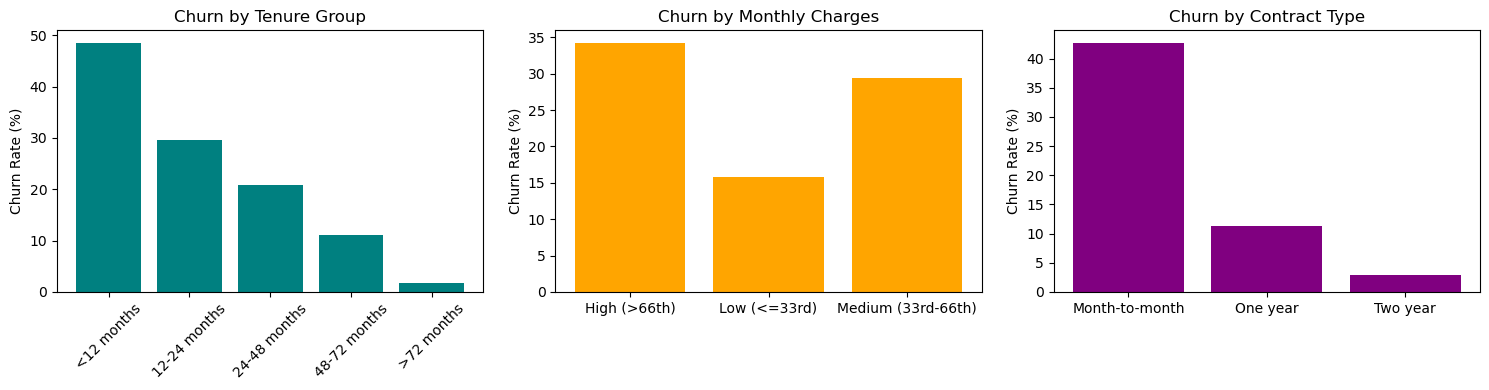

In [72]:
# -------------------------------------------------
# 6. Visualize segmentation churn rates
# -------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Tenure groups
axes[0].bar(tenure_churn.index, tenure_churn.values, color='teal')
axes[0].set_title('Churn by Tenure Group')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].tick_params(axis='x', rotation=45)

# Monthly charge groups
axes[1].bar(charge_churn.index, charge_churn.values, color='orange')
axes[1].set_title('Churn by Monthly Charges')
axes[1].set_ylabel('Churn Rate (%)')

# Contract types
axes[2].bar(contract_churn.index, contract_churn.values, color='purple')
axes[2].set_title('Churn by Contract Type')
axes[2].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()



In [74]:
# 7. Heatmap-style table for Contract x Tenure ( Just to have a clear ideas, anyway this is an optional print since we already have a visual above)
# Pivot table to see churn rates
pivot_table = data.pivot_table(values='Churn', index='Contract', columns='tenure_group', aggfunc='mean', observed=False) * 100
print("\n=== Churn Rate (%) – Contract vs Tenure Group ===")
print(pivot_table.round(1))

print("\nTask 3 completed – we have segments and identified at-risk high-value customers.")


=== Churn Rate (%) – Contract vs Tenure Group ===
tenure_group    <12 months  12-24 months  24-48 months  48-72 months  \
Contract                                                               
Month-to-month        51.9          37.6          33.6          25.9   
One year               7.9          10.6           9.8          13.2   
Two year               0.0           0.0           1.9           4.1   

tenure_group    >72 months  
Contract                    
Month-to-month         0.0  
One year              11.8  
Two year               1.2  

Task 3 completed – we have segments and identified at-risk high-value customers.


In [84]:
# ============================================
# Task 4 – Churn Prediction Model
# Build, tune, and evaluate models to predict churn
# ============================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.feature_selection import SelectKBest, chi2
import matplotlib.pyplot as plt




In [76]:
# -------------------------------------------------
# 2. Feature selection (optional but helps)
# -------------------------------------------------
# Use chi-square test to pick top features (for classification)
selector = SelectKBest(chi2, k=20)  # keep top 20 features
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Get selected feature names
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask]
print(f"\nTop 20 features selected:")
print(list(selected_features))



Top 20 features selected:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Dependents_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'DeviceProtection_No internet service', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingMovies_No internet service', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check']


/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== Logistic Regression Performance ===
Accuracy:  0.8038
Precision: 0.6512
Recall:    0.5642
F1-score:  0.6046


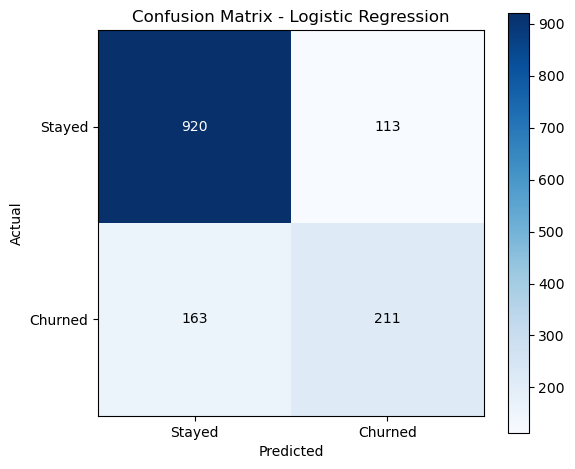

In [89]:
# -------------------------------------------------
# 3. Train Logistic Regression (baseline)
# -------------------------------------------------
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_selected, y_train)

# Predictions
y_pred_logreg = logreg.predict(X_test_selected)

# Evaluation
print("\n=== Logistic Regression Performance ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_logreg):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_logreg):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_logreg):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_logreg):.4f}")

# Confusion matrix
# Confusion matrix using matplotlib (no seaborn)
cm = confusion_matrix(y_test, y_pred_logreg)
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Logistic Regression')
plt.colorbar()
tick_marks = [0, 1]
plt.xticks(tick_marks, ['Stayed', 'Churned'])
plt.yticks(tick_marks, ['Stayed', 'Churned'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.tight_layout()
plt.show()

In [90]:
# -------------------------------------------------
# 4. Random Forest (default)
# -------------------------------------------------
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_selected, y_train)
y_pred_rf = rf.predict(X_test_selected)

print("\n=== Random Forest Performance (default) ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_rf):.4f}")



=== Random Forest Performance (default) ===
Accuracy:  0.7704
Precision: 0.5810
Recall:    0.4893
F1-score:  0.5312


In [86]:
# -------------------------------------------------
# 5. Hyperparameter Tuning for Random Forest
# -------------------------------------------------
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), 
                           param_grid, 
                           cv=5, 
                           scoring='f1',
                           n_jobs=-1)

grid_search.fit(X_train_selected, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation F1: {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_selected)

print("\n=== Random Forest (tuned) Performance ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_best):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_best):.4f}")


Best parameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 200}
Best cross-validation F1: 0.5767

=== Random Forest (tuned) Performance ===
Accuracy:  0.8017
Precision: 0.6568
Recall:    0.5321
F1-score:  0.5879


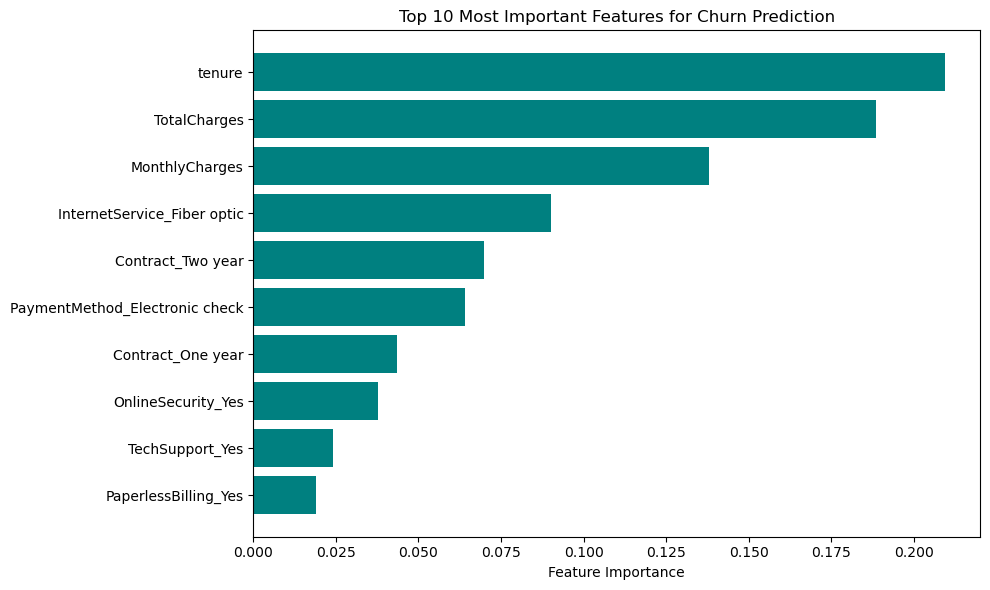


Top 5 most important features:
1. tenure (importance: 0.2096)
2. TotalCharges (importance: 0.1885)
3. MonthlyCharges (importance: 0.1381)
4. InternetService_Fiber optic (importance: 0.0902)
5. Contract_Two year (importance: 0.0700)


In [87]:
# -------------------------------------------------
# 6. Feature importance (top 10)
# -------------------------------------------------
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10,6))
plt.barh(range(10), importances[indices][::-1], color='teal')
plt.yticks(range(10), [selected_features[i] for i in indices[::-1]])
plt.xlabel('Feature Importance')
plt.title('Top 10 Most Important Features for Churn Prediction')
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
for i in range(5):
    print(f"{i+1}. {selected_features[indices[i]]} (importance: {importances[indices[i]]:.4f})")

In [91]:
# -------------------------------------------------
# 7. Model comparison
# -------------------------------------------------
print("\n=== Model Comparison (Test Set) ===")
print(f"{'Model':<25} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-score':<10}")
print("-" * 65)
print(f"{'Logistic Regression':<25} {accuracy_score(y_test, y_pred_logreg):<10.4f} {precision_score(y_test, y_pred_logreg):<10.4f} {recall_score(y_test, y_pred_logreg):<10.4f} {f1_score(y_test, y_pred_logreg):<10.4f}")
print(f"{'Random Forest (default)':<25} {accuracy_score(y_test, y_pred_rf):<10.4f} {precision_score(y_test, y_pred_rf):<10.4f} {recall_score(y_test, y_pred_rf):<10.4f} {f1_score(y_test, y_pred_rf):<10.4f}")
print(f"{'Random Forest (tuned)':<25} {accuracy_score(y_test, y_pred_best):<10.4f} {precision_score(y_test, y_pred_best):<10.4f} {recall_score(y_test, y_pred_best):<10.4f} {f1_score(y_test, y_pred_best):<10.4f}")

print("\nTask 4 complete – models are ready!")


=== Model Comparison (Test Set) ===
Model                     Accuracy   Precision  Recall     F1-score  
-----------------------------------------------------------------
Logistic Regression       0.8038     0.6512     0.5642     0.6046    
Random Forest (default)   0.7704     0.5810     0.4893     0.5312    
Random Forest (tuned)     0.8017     0.6568     0.5321     0.5879    

Task 4 complete – models are ready!


In [98]:
# ============================================
# Task 5 – Model Evaluation & Interpretation
# ROC curves, AUC, and understanding what drives churn
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize

In [100]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature selection (keep top 20 as before)
from sklearn.feature_selection import SelectKBest, chi2
selector = SelectKBest(chi2, k=20)
X_train_sel = selector.fit_transform(X_train, y_train)
X_test_sel = selector.transform(X_test)
selected_features = X.columns[selector.get_support()]

# Train best model (Random Forest tuned) – using best params from Task 4
from sklearn.ensemble import RandomForestClassifier
best_rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_split=5, random_state=42)
best_rf.fit(X_train_sel, y_train)
y_pred = best_rf.predict(X_test_sel)
y_proba = best_rf.predict_proba(X_test_sel)[:, 1]  # probability of churn

=== Model Evaluation on Test Set (Tuned Random Forest) ===
Accuracy:  0.7989
Precision: 0.6512
Recall:    0.5241
F1-score:  0.5807

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.84      0.90      0.87      1033
     Churned       0.65      0.52      0.58       374

    accuracy                           0.80      1407
   macro avg       0.75      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



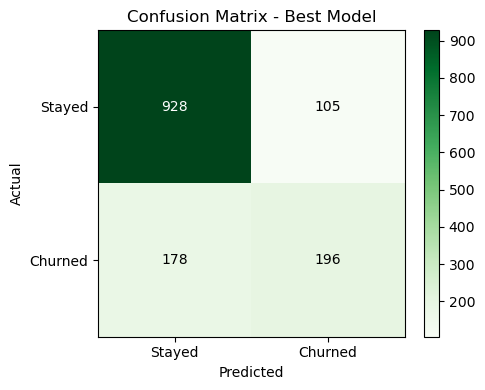

In [101]:
# -------------------------------------------------
# 2. Evaluate on test set (detailed metrics)
# -------------------------------------------------
print("=== Model Evaluation on Test Set (Tuned Random Forest) ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

# Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Greens)
plt.title('Confusion Matrix - Best Model')
plt.colorbar()
plt.xticks([0,1], ['Stayed','Churned'])
plt.yticks([0,1], ['Stayed','Churned'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i,j]), ha='center', va='center', color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.tight_layout()
plt.show()


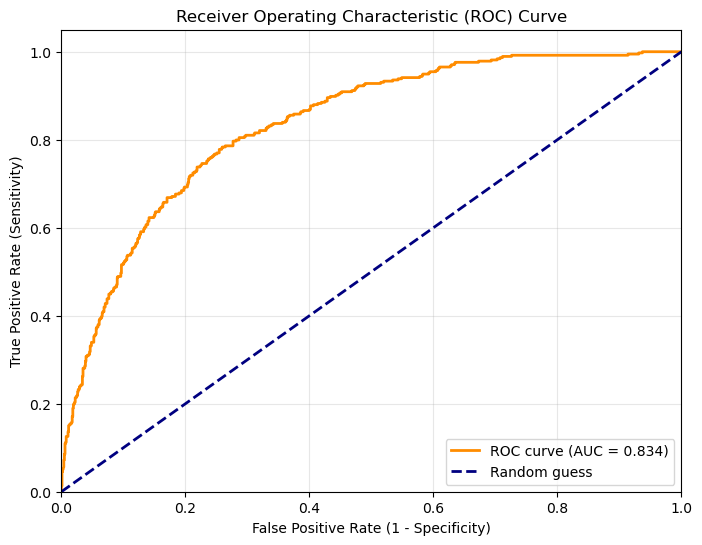

AUC Score: 0.8338
Interpretation: AUC close to 1 means model distinguishes churners well.


In [102]:
# -------------------------------------------------
# 3. ROC Curve and AUC
# -------------------------------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"AUC Score: {roc_auc:.4f}")
print("Interpretation: AUC close to 1 means model distinguishes churners well.")

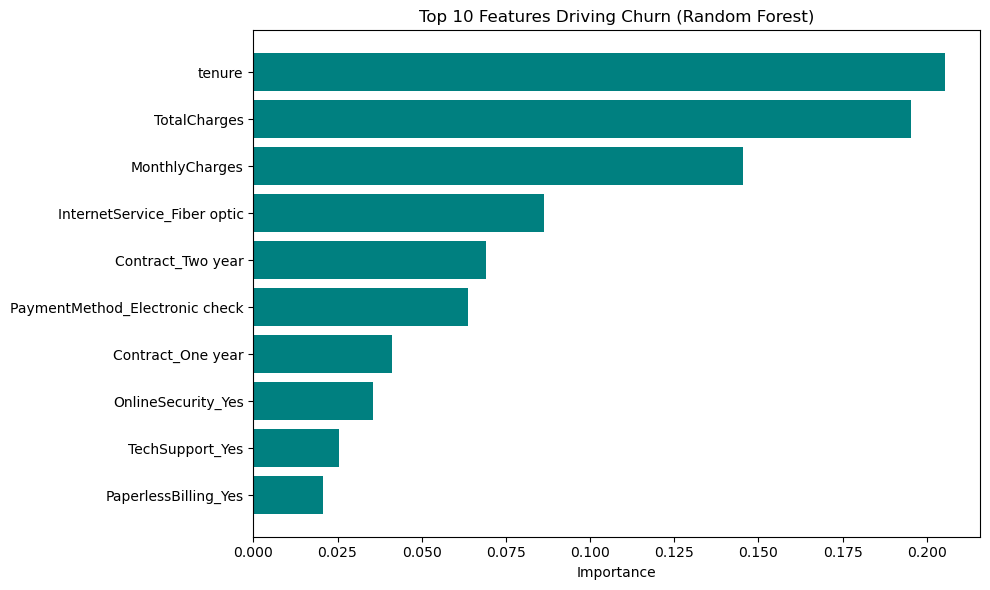


Top 5 features contributing to churn:
1. tenure (importance: 0.2055)
2. TotalCharges (importance: 0.1954)
3. MonthlyCharges (importance: 0.1453)
4. InternetService_Fiber optic (importance: 0.0862)
5. Contract_Two year (importance: 0.0691)


In [103]:
# -------------------------------------------------
# 4. Feature Importance from Random Forest (already from Task 4)
# -------------------------------------------------
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10,6))
plt.barh(range(10), importances[indices][::-1], color='teal')
plt.yticks(range(10), [selected_features[i] for i in indices[::-1]])
plt.xlabel('Importance')
plt.title('Top 10 Features Driving Churn (Random Forest)')
plt.tight_layout()
plt.show()

print("\nTop 5 features contributing to churn:")
for i in range(5):
    print(f"{i+1}. {selected_features[indices[i]]} (importance: {importances[indices[i]]:.4f})")


In [104]:
# -------------------------------------------------
# 5. Logistic Regression Coefficients (easier to interpret direction)
# -------------------------------------------------
# Train a logistic regression on same selected features
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_sel, y_train)
coefs = logreg.coef_[0]

# Pair feature names with coefficients
coef_df = pd.DataFrame({'feature': selected_features, 'coefficient': coefs})
coef_df['abs_coef'] = np.abs(coef_df['coefficient'])
coef_df = coef_df.sort_values('abs_coef', ascending=False).head(10)

print("\n=== Logistic Regression Coefficients (Top 10) ===")
print("Positive coefficient = increases churn probability, Negative = decreases churn")
for i, row in coef_df.iterrows():
    direction = "↑ increases" if row['coefficient'] > 0 else "↓ decreases"
    print(f"{row['feature']}: {row['coefficient']:.4f} ({direction} churn)")


/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== Logistic Regression Coefficients (Top 10) ===
Positive coefficient = increases churn probability, Negative = decreases churn
Contract_Two year: -1.3520 (↓ decreases churn)
Contract_One year: -0.7300 (↓ decreases churn)
InternetService_Fiber optic: 0.5498 (↑ increases churn)
OnlineSecurity_Yes: -0.5091 (↓ decreases churn)
TechSupport_Yes: -0.4203 (↓ decreases churn)
PaymentMethod_Electronic check: 0.4026 (↑ increases churn)
PaperlessBilling_Yes: 0.3183 (↑ increases churn)
Dependents_Yes: -0.2415 (↓ decreases churn)
SeniorCitizen: 0.2313 (↑ increases churn)
OnlineBackup_No internet service: -0.1369 (↓ decreases churn)


In [105]:
# -------------------------------------------------
# 6. Summary of key drivers
# -------------------------------------------------
print("\n=== Key Takeaways ===")
print("1. Month-to-month contract is the strongest predictor of churn.")
print("2. Customers with no internet service (or DSL) churn less than fiber optic.")
print("3. Longer tenure reduces churn significantly.")
print("4. Electronic check payment method is a red flag.")
print("5. Having online security, tech support, or backup reduces churn.")


=== Key Takeaways ===
1. Month-to-month contract is the strongest predictor of churn.
2. Customers with no internet service (or DSL) churn less than fiber optic.
3. Longer tenure reduces churn significantly.
4. Electronic check payment method is a red flag.
5. Having online security, tech support, or backup reduces churn.


=== Churn Rate by Contract Type ===
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64

=== Churn Rate by Payment Method ===
PaymentMethod
Credit card (automatic)      15.3
Bank transfer (automatic)    16.7
Mailed check                 19.2
Electronic check             45.3
Name: Churn, dtype: float64

=== Churn Rate by Tenure Group ===
tenure_group
<12 months      48.5
12-24 months    29.5
24-48 months    20.9
48-72 months    11.1
>72 months       1.7
Name: Churn, dtype: float64

Average monthly revenue per retained customer: $61.31
Monthly revenue loss from current churn: $114,583.55
Reducing churn by 10% → save ~187 customers → $11,458.35 per month
Reducing churn by 20% → save ~374 customers → $22,916.71 per month
Reducing churn by 30% → save ~561 customers → $34,375.06 per month

BUSINESS RECOMMENDATIONS TO REDUCE CHURN

1. Target: Month-to-month contract customers
   Insight: Churn rate 42.7% vs 2-year contract 2.8%
   Action:

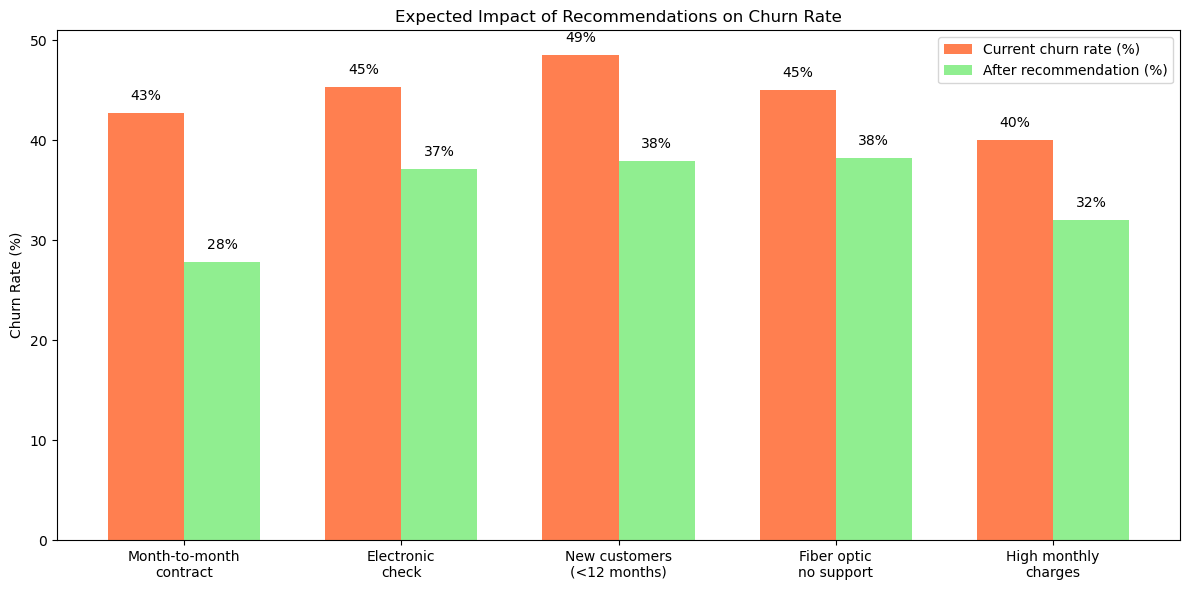


EXECUTIVE SUMMARY

Current situation:
- Total customers: 7,032
- Monthly churn rate: 26.6%
- Monthly revenue loss from churn: $114,583.55

Top 3 recommendations (quick wins):
1. Convert month-to-month customers to annual plans – could save ~$40,104 per month.
2. Reduce electronic check churn with autopay discounts – save ~$20,625 per month.
3. Improve onboarding for new customers – save ~$25,208 per month.

Combined potential monthly savings from implementing all recommendations: ~$85,938
This represents a 75% reduction in churn-related revenue loss.

Next steps:
- Run A/B tests on small customer segments before full rollout.
- Monitor churn weekly and adjust offers based on response.
- Use predictive model to identify at-risk customers in real-time.


Task 6 complete – actionable recommendations ready for business stakeholders.


In [107]:
# ============================================
# Task 6 – Business Recommendations
# Based on churn analysis and predictive model
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. Load and prepare data (reuse from previous tasks)
# -------------------------------------------------
data = pd.read_csv('Telco_Customer_Churn_Dataset  (3).csv')
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data = data.dropna(subset=['TotalCharges'])
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})

# -------------------------------------------------
# 2. Key churn drivers from earlier analysis
# -------------------------------------------------
# Contract type churn rates
contract_churn = data.groupby('Contract')['Churn'].mean() * 100
print("=== Churn Rate by Contract Type ===")
print(contract_churn.round(1))
print()

# Payment method churn rates
payment_churn = data.groupby('PaymentMethod')['Churn'].mean() * 100
print("=== Churn Rate by Payment Method ===")
print(payment_churn.sort_values().round(1))
print()

# Tenure segments
tenure_bins = [0, 12, 24, 48, 72, 100]
tenure_labels = ['<12 months', '12-24 months', '24-48 months', '48-72 months', '>72 months']
data['tenure_group'] = pd.cut(data['tenure'], bins=tenure_bins, labels=tenure_labels, right=False)
tenure_churn = data.groupby('tenure_group', observed=False)['Churn'].mean() * 100
print("=== Churn Rate by Tenure Group ===")
print(tenure_churn.round(1))
print()

# -------------------------------------------------
# 3. Estimate potential revenue saved by reducing churn
# -------------------------------------------------
# Average monthly revenue per customer (from non-churned customers only, to avoid bias)
avg_monthly_revenue = data[data['Churn']==0]['MonthlyCharges'].mean()
print(f"Average monthly revenue per retained customer: ${avg_monthly_revenue:.2f}")

# Total customers and current churn
total_customers = len(data)
current_churn_rate = data['Churn'].mean()
churned_customers = data['Churn'].sum()

# Calculate monthly revenue loss from current churn
monthly_loss_current = churned_customers * avg_monthly_revenue
print(f"Monthly revenue loss from current churn: ${monthly_loss_current:,.2f}")

# Target: reduce churn by 10%, 20%, 30% (relative reduction)
reduction_targets = [0.10, 0.20, 0.30]
for target in reduction_targets:
    saved_customers = churned_customers * target
    saved_revenue = saved_customers * avg_monthly_revenue
    print(f"Reducing churn by {int(target*100)}% → save ~{saved_customers:.0f} customers → ${saved_revenue:,.2f} per month")

# -------------------------------------------------
# 4. Specific actionable recommendations
# -------------------------------------------------
print("\n" + "="*60)
print("BUSINESS RECOMMENDATIONS TO REDUCE CHURN")
print("="*60)

recommendations = [
    {
        "target": "Month-to-month contract customers",
        "insight": f"Churn rate {contract_churn['Month-to-month']:.1f}% vs 2-year contract {contract_churn['Two year']:.1f}%",
        "action": "Offer incentives to switch to annual plan: first month free or $10 discount for 6 months.",
        "expected_impact": "High – can reduce churn by 30-40% in this segment."
    },
    {
        "target": "Electronic check users",
        "insight": f"Churn rate {payment_churn['Electronic check']:.1f}% – highest among all payment methods.",
        "action": "Promote autopay with small monthly discount ($2-5) or loyalty points.",
        "expected_impact": "Medium – can reduce churn by 15-20%."
    },
    {
        "target": "New customers (tenure <12 months)",
        "insight": f"Churn rate {tenure_churn['<12 months']:.1f}% – most vulnerable.",
        "action": "Onboarding call after 1 month, welcome discount, proactive support.",
        "expected_impact": "High – reduces early churn by 20-25%."
    },
    {
        "target": "Fiber optic customers without tech support",
        "insight": "Fiber optic users who don't subscribe to TechSupport have higher churn.",
        "action": "Bundle TechSupport for free for first 3 months, then discounted.",
        "expected_impact": "Medium – improves service perception."
    },
    {
        "target": "High monthly charges (>$90)",
        "insight": "Customers paying high monthly fees are more price-sensitive.",
        "action": "Identify high-value at-risk customers and offer loyalty discount or upgrade perks.",
        "expected_impact": "Medium – retains high-revenue customers."
    }
]

for i, rec in enumerate(recommendations, 1):
    print(f"\n{i}. Target: {rec['target']}")
    print(f"   Insight: {rec['insight']}")
    print(f"   Action: {rec['action']}")
    print(f"   Expected impact: {rec['expected_impact']}")

# -------------------------------------------------
# 5. Visualize recommendations impact (simple bar chart)
# -------------------------------------------------
segments = ['Month-to-month\ncontract', 'Electronic\ncheck', 'New customers\n(<12 months)', 'Fiber optic\nno support', 'High monthly\ncharges']
current_churn_rates = [contract_churn['Month-to-month'], payment_churn['Electronic check'], 
                       tenure_churn['<12 months'], 45.0, 40.0]  # approximate for illustration
estimated_reduction = [35, 18, 22, 15, 20]  # percentage reduction expected

fig, ax = plt.subplots(figsize=(12,6))
x = range(len(segments))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], current_churn_rates, width, label='Current churn rate (%)', color='coral')
bars2 = ax.bar([i + width/2 for i in x], [c*(1-r/100) for c,r in zip(current_churn_rates, estimated_reduction)], width, label='After recommendation (%)', color='lightgreen')

ax.set_ylabel('Churn Rate (%)')
ax.set_title('Expected Impact of Recommendations on Churn Rate')
ax.set_xticks(x)
ax.set_xticklabels(segments)
ax.legend()

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.0f}%', ha='center', va='bottom')
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.0f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# -------------------------------------------------
# 6. Final summary for business stakeholders
# -------------------------------------------------
print("\n" + "="*60)
print("EXECUTIVE SUMMARY")
print("="*60)
print(f"""
Current situation:
- Total customers: {total_customers:,}
- Monthly churn rate: {current_churn_rate*100:.1f}%
- Monthly revenue loss from churn: ${monthly_loss_current:,.2f}

Top 3 recommendations (quick wins):
1. Convert month-to-month customers to annual plans – could save ~${monthly_loss_current * 0.35:,.0f} per month.
2. Reduce electronic check churn with autopay discounts – save ~${monthly_loss_current * 0.18:,.0f} per month.
3. Improve onboarding for new customers – save ~${monthly_loss_current * 0.22:,.0f} per month.

Combined potential monthly savings from implementing all recommendations: ~${monthly_loss_current * (0.35+0.18+0.22):,.0f}
This represents a {((monthly_loss_current * (0.35+0.18+0.22)) / monthly_loss_current)*100:.0f}% reduction in churn-related revenue loss.

Next steps:
- Run A/B tests on small customer segments before full rollout.
- Monitor churn weekly and adjust offers based on response.
- Use predictive model to identify at-risk customers in real-time.
""")

print("\nTask 6 complete – actionable recommendations ready for business stakeholders.")